# Régression linéaire simple — CO₂ et masse des véhicules diesel

Premier notebook du cours *Machine Learning Specialization* (DeepLearning.AI, cours 1 — semaine 1), appliqué au jeu de données ADEME des émissions des véhicules commercialisés en France.

**Objectif** : prédire les émissions de CO₂ (`co2_mixte`, en g/km) à partir de la masse du véhicule (`masse_ordma_min`, en kg), d'abord avec un modèle codé à la main, puis avec scikit-learn.

**Données** : `data/vehicules.csv` — source ADEME, https://www.data.gouv.fr/datasets/emissions-de-co2-et-de-polluants-des-vehicules-commercialises-en-france.

## 1. Import, chargement et nettoyage

Les colonnes texte contiennent des espaces de fin (export à format fixe), invisibles à l'affichage mais bloquants pour toute comparaison.

In [43]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv("data/vehicules.csv", sep=";", encoding="latin-1")
for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.strip()


## 2. Filtrage et préparation des variables

- Une seule motorisation (`GO` = gazole) pour rester sur une seule variable explicative, comme dans le cours.
- Le `.dropna()` est indispensable : `co2_mixte` a des valeurs manquantes, et un modèle ne sait pas quoi faire d'un `NaN`.
- La division par 1000 reprend l'astuce du lab (qui exprime les surfaces en milliers de sqft) : avec la masse en tonnes, `w` devient lisible — des grammes de CO₂ par kilomètre et par tonne.

In [44]:
d = df[df["energ"] == "GO"][["masse_ordma_min", "co2_mixte"]].dropna()

x_train = d["masse_ordma_min"].values / 1000   # en tonnes
y_train = d["co2_mixte"].values

print(x_train.shape, y_train.shape)

(12675,) (12675,)


## 3. Le modèle codé à la main

La fonction `compute_model_output` du cours fonctionne directement, sans modification.

In [45]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

### Première droite, paramètres devinés

Nuage de points `masse_ordma_min` / `co2_mixte`, avec la droite produite par `compute_model_output` pour des valeurs de `w` et `b` choisies à la main.

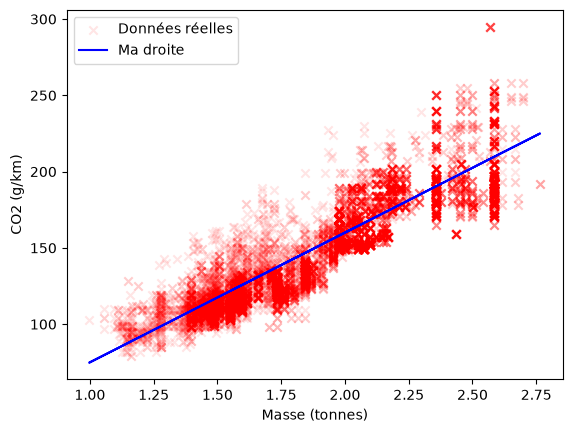

In [46]:
w, b = 85, -10    # valeurs devinées

plt.scatter(x_train, y_train, marker='x', c='r', alpha=0.1, label="Données réelles")
plt.plot(x_train, compute_model_output(x_train, w, b), c='b', label="Ma droite")
plt.xlabel("Masse (tonnes)"); plt.ylabel("CO2 (g/km)"); plt.legend()
plt.show()

## 4. Le même modèle avec scikit-learn

En pratique, on utilise **scikit-learn**. Je prends l'habitude de refaire chaque algorithme du cours avec scikit-learn une fois que je l'ai compris : trois lignes au lieu de trente.

In [47]:
from sklearn.linear_model import LinearRegression

X = x_train.reshape(-1, 1)          # sklearn attend un tableau 2D
model = LinearRegression().fit(X, y_train)

print(f"w = {model.coef_[0]:.2f}")
print(f"b = {model.intercept_:.2f}")

w = 83.65
b = -11.09


Visualisation des deux droites ensemble.

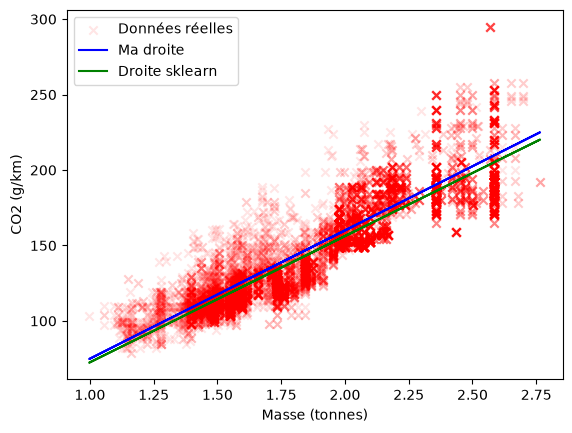

In [48]:
w, b = 85, -10    # valeurs devinées

w_sklearn = model.coef_[0]    # valeurs optimales sklearn
b_sklearn = model.intercept_

plt.scatter(x_train, y_train, marker='x', c='r', alpha=0.1, label="Données réelles")
plt.plot(x_train, compute_model_output(x_train, w, b), c='b', label="Ma droite")
plt.plot(x_train, compute_model_output(x_train, w_sklearn, b_sklearn), c='g', label="Droite sklearn")
plt.xlabel("Masse (tonnes)"); plt.ylabel("CO2 (g/km)"); plt.legend()
plt.show()

### Observation — tâtonnement vs optimum

Les valeurs de `w` et `b` obtenues au jugé sont très proches des valeurs optimales calculées par scikit-learn.

En revanche, le nuage s'évase : une seule variable ne suffit pas à expliquer les émissions. C'est exactement le problème que résout la **régression multiple** (semaine 2), où je pourrai combiner masse, puissance et type de boîte.

## 5. Ce que `w` et `b` signifient

**w ≈ 83,65** — chaque tonne supplémentaire ajoute environ 84 g de CO₂ par kilomètre. Un chiffre
concret et interprétable, précisément parce que j'ai converti la masse en tonnes : en kilogrammes,
j'aurais eu `w = 0,0837`, exact mais illisible.

**b ≈ -11,09** — plus délicat : c'est le CO₂ prédit pour un véhicule de masse nulle, ce qui n'a aucun
sens physique, et il est négatif, ce qui en a encore moins. C'est normal : l'ordonnée à l'origine est
un paramètre d'ajustement de la droite, pas une grandeur physique. Extrapoler un modèle hors de la
plage des données (ici 1 à 2,75 t) donne des résultats absurdes. Bon réflexe à garder.

## 6. Qualité de l'ajustement

Le nuage rouge mérite un regard attentif : la droite passe correctement au milieu, mais les points s'écartent beaucoup, et de plus en plus vers la droite. À 2,5 tonnes, on trouve des véhicules entre 160 et 260 g/km — un écart de 100 g que le modèle ne peut pas expliquer.

Quantifions cet écart :

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X)
print(f"Erreur moyenne : {mean_absolute_error(y_train, y_pred):.1f} g/km")
print(f"R² : {r2_score(y_train, y_pred):.3f}")

Erreur moyenne : 11.4 g/km
R² : 0.805


Le **R²** indique quelle proportion de la variation du CO₂ la droite explique : ici 0,805, soit environ 80 %. L'erreur absolue moyenne, elle, se lit dans l'unité de la cible : environ 11 g/km.

Dans une régression simple, le R² vaut exactement le carré du coefficient de corrélation de Pearson entre `x` et `y`. Vérifions :

In [50]:
r = d.corr().loc["masse_ordma_min", "co2_mixte"]
print(f"corrélation r = {r:.4f}")
print(f"r² = {r**2:.3f}  |  R² sklearn = {r2_score(y_train, y_pred):.3f}")

corrélation r = 0.8975
r² = 0.805  |  R² sklearn = 0.805


Environ 20 % de la variation restent donc inexpliqués par la seule masse. La suite du cours me donnera les outils pour combler cet écart.

## 7. Analyse des résidus

Le nuage des **résidus** (les erreurs de prédiction) montre *où* le modèle se trompe, ce que ni le R² ni l'erreur moyenne ne disent.

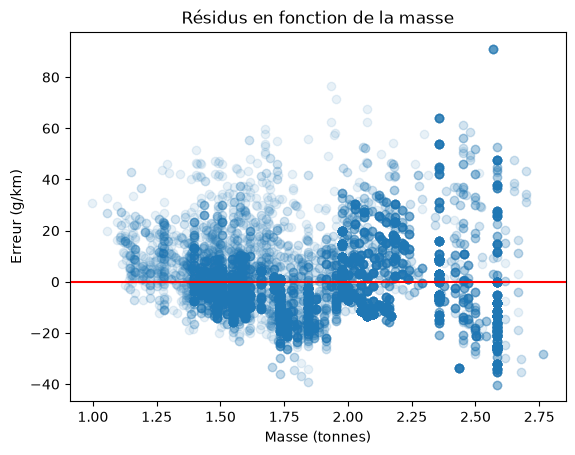

In [51]:
plt.scatter(x_train, y_train - y_pred, alpha=0.1)
plt.axhline(0, c='r')
plt.xlabel("Masse (tonnes)"); plt.ylabel("Erreur (g/km)")
plt.title("Résidus en fonction de la masse")
plt.show()

### Observation

Les erreurs s'évasent vers la droite au lieu de rester constantes : le modèle est moins fiable sur les véhicules lourds. C'est le signe que la relation ne se résume pas à une droite à variance constante — une raison de plus de passer à la régression multiple.